# Mesma coisa do v3 mas usando apenas 80% do dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from feature_engine.selection import MRMR


dataset = pd.read_csv("../dataset/riemann_features.csv")

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

split = int(0.8 * len(X))
X = X[:split]
y = y[:split]

def plot_top_features(importance: pd.Series, title: str, xlabel: str, ylabel: str) -> None:
    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh", color="gray")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# FEATURE SELECTION

## Correlation

--- Method (i): Correlation Ranking ---


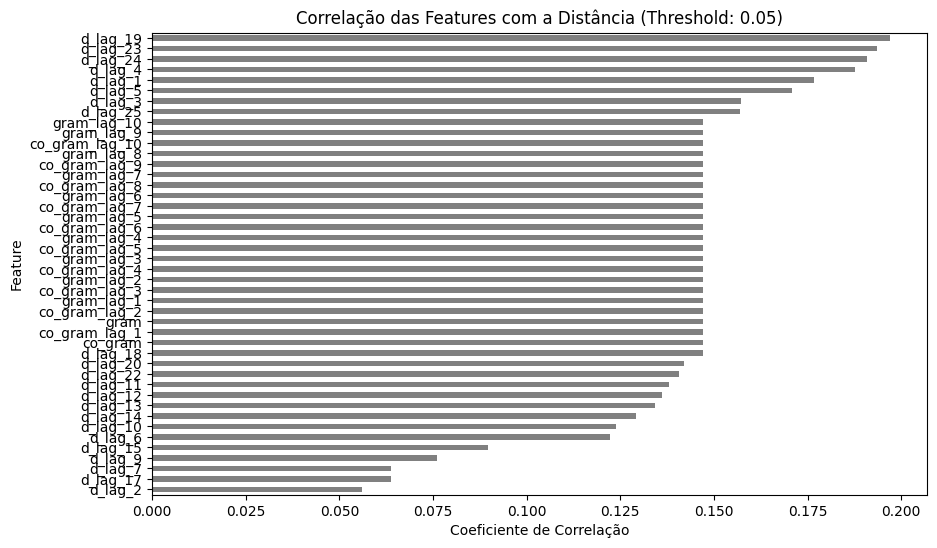

In [8]:
print("--- Method (i): Correlation Ranking ---")
correlations = X_train.corrwith(y_train)
threshold = 0.05
sorted_correlation_rank = correlations.abs().sort_values(ascending=False)
top_features = sorted_correlation_rank[sorted_correlation_rank > threshold]

top_features.index.to_series().to_csv("../results/correlation_feature_selection_v4.csv", index=False, header=["feature"])

plot_top_features(
    top_features,
    f"Correlação das Features com a Distância (Threshold: {threshold})",
    "Coeficiente de Correlação",
    "Feature"
)

## Random Forest

--- Random Forest Importance Ranking ---


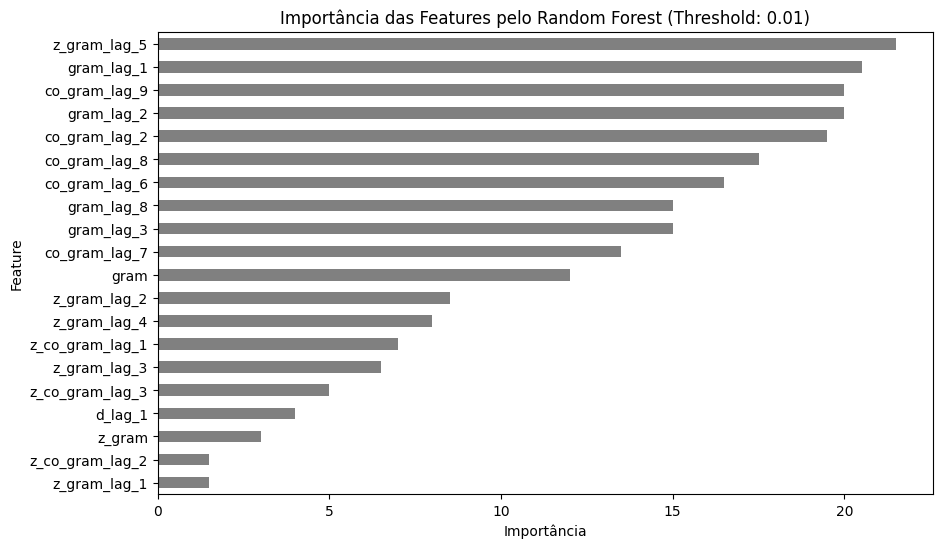

In [9]:
print("--- Random Forest Importance Ranking ---")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

rf_purity = pd.Series(rf_model.feature_importances_, index=X.columns)

perm_result = permutation_importance(rf_model, X, y, n_repeats=10, random_state=42, n_jobs=1)
rf_accuracy = pd.Series(perm_result.importances_mean, index=X.columns)

combined_rank = (rf_purity.rank(ascending=False) + rf_accuracy.rank(ascending=False)) / 2
top_features = combined_rank.sort_values().head(20)

result_df = pd.DataFrame({"feature": top_features.index})
result_df.to_csv("../results/random_forest_feature_selection_v4.csv", index=False)

plot_top_features(
    top_features,
    "Importância das Features pelo Random Forest (Threshold: 0.01)",
    "Importância",
    "Feature"
)

## Gevrey Weights Method

--- Method (iii) Neural Network Importance Ranking (Gevrey) ---
z_term_3           2.982030
z_term_2           2.440738
z_co_gram_lag_2    1.853212
z_co_gram_lag_1    1.671669
d_lag_1            1.604984
                     ...   
d_lag_25           0.759132
z_term_6           0.717058
z_term_4           0.707099
z_integer_lag_2    0.689857
d_lag_24           0.645476
Length: 94, dtype: float64


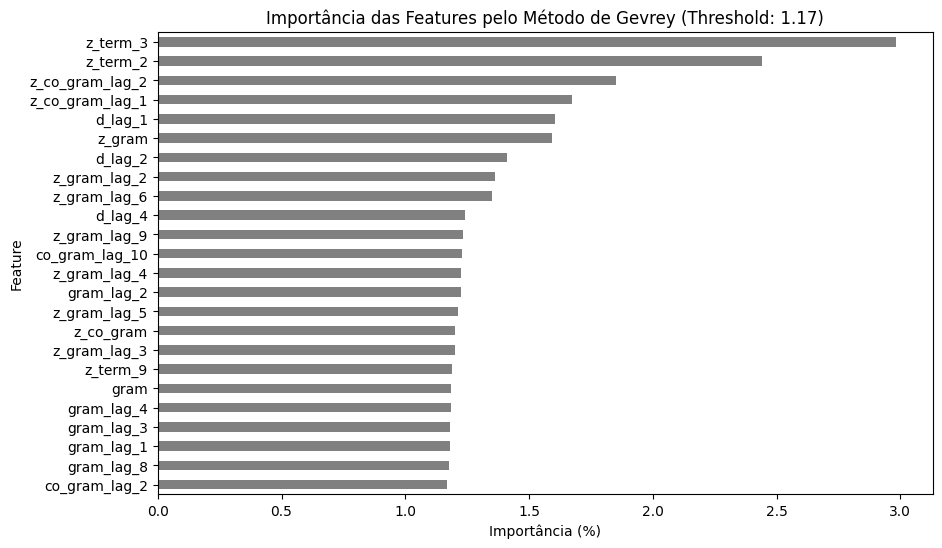

In [10]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("--- Method (iii) Neural Network Importance Ranking (Gevrey) ---")

nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
nn_model.fit(X_scaled, y)

W = nn_model.coefs_[0] # matriz de pesos entre a camada de entrada e a primeira camada oculta
ni = W.shape[0]
nh = W.shape[1]

Q = np.zeros((ni, nh))

for h in range(nh):
    soma_pesos = 0
    for i in range(ni):
        soma_pesos += abs(W[i, h])
    for i in range(ni):
        Q[i, h] = abs(W[i, h]) / soma_pesos

soma_total = 0
for h in range(nh):
    for i in range(ni):
        soma_total += Q[i, h]

RI = np.zeros(ni)

for i in range(ni):
    soma_h = 0
    for h in range(nh):
        soma_h += Q[i, h]
    RI[i] = (soma_h / soma_total) * 100

nn_importance = pd.Series(RI, index=X.columns)
nn_importance_sorted = nn_importance.sort_values(ascending=False)

print(nn_importance_sorted)

threshold_nn = np.percentile(RI, 75)
final_ranked_features = nn_importance[nn_importance > threshold_nn].sort_values(ascending=False)

final_ranked_features.index\
    .to_series()\
    .to_csv("../results/gevrey_method_feature_selection_v4.csv", index=False, header=["feature"])

plot_top_features(
    final_ranked_features,
    f"Importância das Features pelo Método de Gevrey (Threshold: {threshold_nn:.2f})",
    "Importância (%)",
    "Feature"
)

# Garson

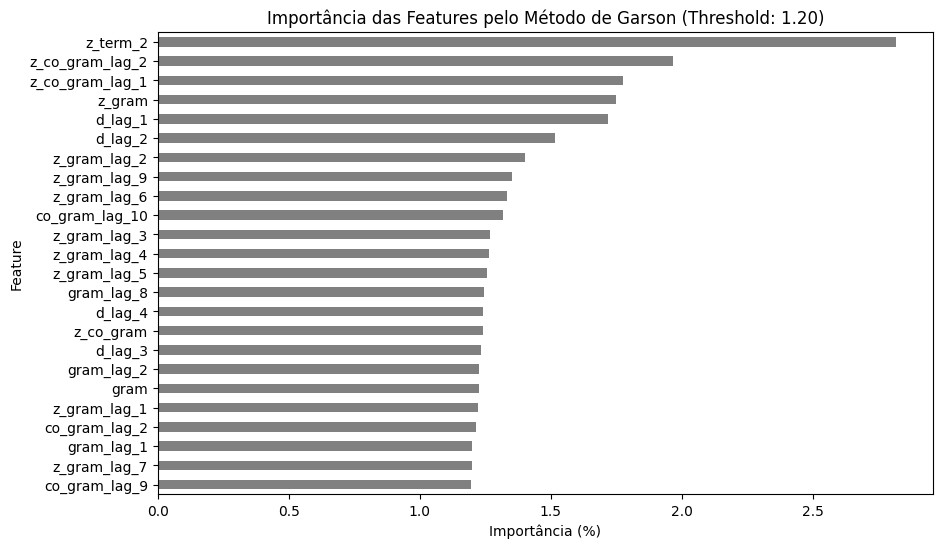

In [11]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
nn_model.fit(X_scaled, y)

W = nn_model.coefs_[0]
V = nn_model.coefs_[1]

ni, nh = W.shape

P = np.zeros((ni, nh))

for h in range(nh):
    for i in range(ni):
        P[i, h] = abs(W[i, h]) * abs(V[h, 0])

Q = np.zeros((ni, nh))

for h in range(nh):
    denom = np.sum(P[:, h])
    if denom == 0:
        continue
    for i in range(ni):
        Q[i, h] = P[i, h] / denom

Q = np.nan_to_num(Q)

S = np.zeros(ni)

for i in range(ni):
    for h in range(nh):
        S[i] += Q[i, h]

RI = (S / S.sum()) * 100

nn_importance = pd.Series(RI, index=X.columns)
nn_importance_sorted = nn_importance.sort_values(ascending=False)

threshold_nn = np.percentile(RI, 75)
final_ranked_features = nn_importance[nn_importance > threshold_nn].sort_values(ascending=False)

final_ranked_features.index.to_series().to_csv(
    "../results/garson_method_feature_selection_v4.csv",
    index=False,
    header=["feature"]
)

plot_top_features(
    final_ranked_features,
    f"Importância das Features pelo Método de Garson (Threshold: {threshold_nn:.2f})",
    "Importância (%)",
    "Feature"
)


## mRMR

In [12]:
feature_numbers = [10, 14, 20]

for feature_number in feature_numbers:
    n_features_mrmr = 10
    mrmr_selector = MRMR(method="MID", regression=True, max_features=feature_number)
    X_mrmr = mrmr_selector.fit_transform(X, y)
    selected_features = X.columns[~X.columns.isin(mrmr_selector.features_to_drop_)]
    pd.DataFrame({"feature": selected_features}).to_csv(f"../results/mrmr_{feature_number}_features_v4.csv", index=False)